# 05. Pre-modeling EDA -- disability strand



## 0. Setup

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed")
FIGURE_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\pre_eda_figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [30]:
dis_level = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_MEMS7GR_all_years.csv')
dis_overall = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_overall_all_years.csv')
dis_dm = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_days_months_all_years.csv')

dis_level['small_cell'] = dis_level['n'] < 30
print('rows:', {'dis_level': len(dis_level), 'dis_overall': len(dis_overall), 'dis_dm': len(dis_dm)})
print('overall small-cell rate:', dis_level['small_cell'].mean().round(3))


rows: {'dis_level': 511488, 'dis_overall': 4096, 'dis_dm': 511488}
overall small-cell rate: 0.692


## 1. Sample size structure


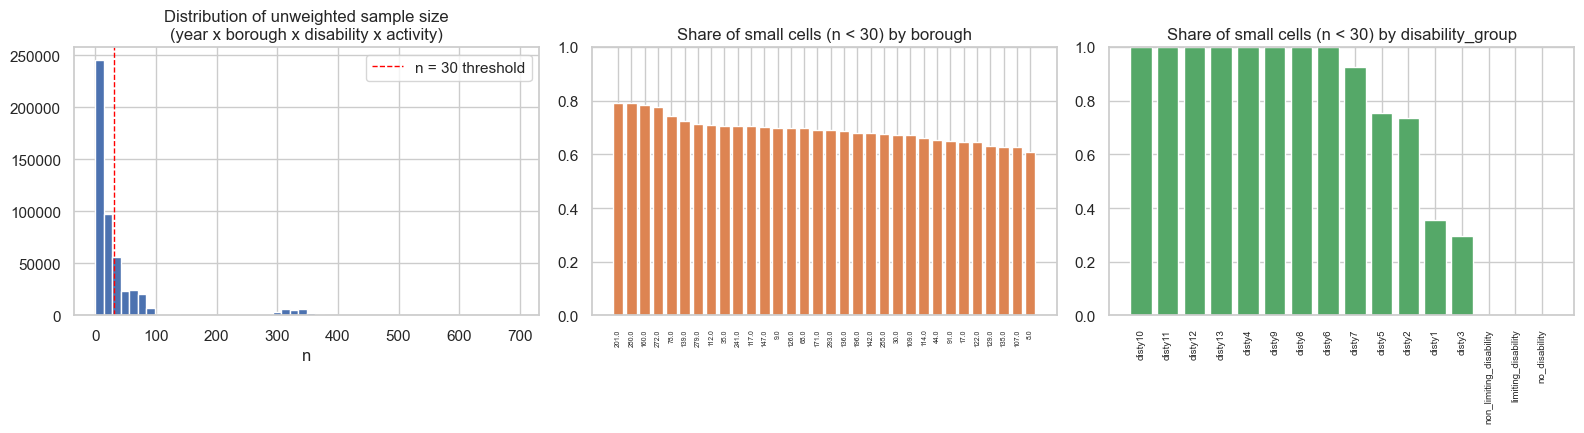

Overall small-cell rate: 69.2%
Boroughs with the highest small-cell rate:
LA_2023
201.0    0.792417
280.0    0.791354
160.0    0.782470
272.0    0.776839
78.0     0.744432
Name: small_cell, dtype: float64
Disability groups with the highest small-cell rate:
disability_group
disty10    1.0
disty11    1.0
disty12    1.0
disty13    1.0
disty4     1.0
Name: small_cell, dtype: float64


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(dis_level['n'].dropna(), bins=50, color='#4C72B0')
axes[0].set_title('Distribution of unweighted sample size\n(year x borough x disability x activity)')
axes[0].set_xlabel('n')
axes[0].axvline(30, color='red', linestyle='--', linewidth=1, label='n = 30 threshold')
axes[0].legend()

by_borough = dis_level.groupby('LA_2023')['small_cell'].mean().sort_values(ascending=False)
axes[1].bar(by_borough.index.astype(str), by_borough.values, color='#DD8452')
axes[1].set_title('Share of small cells (n < 30) by borough')
axes[1].tick_params(axis='x', labelrotation=90, labelsize=5)
axes[1].set_ylim(0, 1)

by_group = dis_level.groupby('disability_group')['small_cell'].mean().sort_values(ascending=False)
axes[2].bar(by_group.index.astype(str), by_group.values, color='#55A868')
axes[2].set_title('Share of small cells (n < 30) by disability_group')
axes[2].tick_params(axis='x', labelrotation=90, labelsize=7)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_01_sample_size_structure.png', dpi=150)
plt.show()

print(f"Overall small-cell rate: {dis_level['small_cell'].mean():.1%}")
print('Boroughs with the highest small-cell rate:')
print(by_borough.head(5))
print('Disability groups with the highest small-cell rate:')
print(by_group.head(5))


## 2. Temporal structure and how predictable the trend actually is


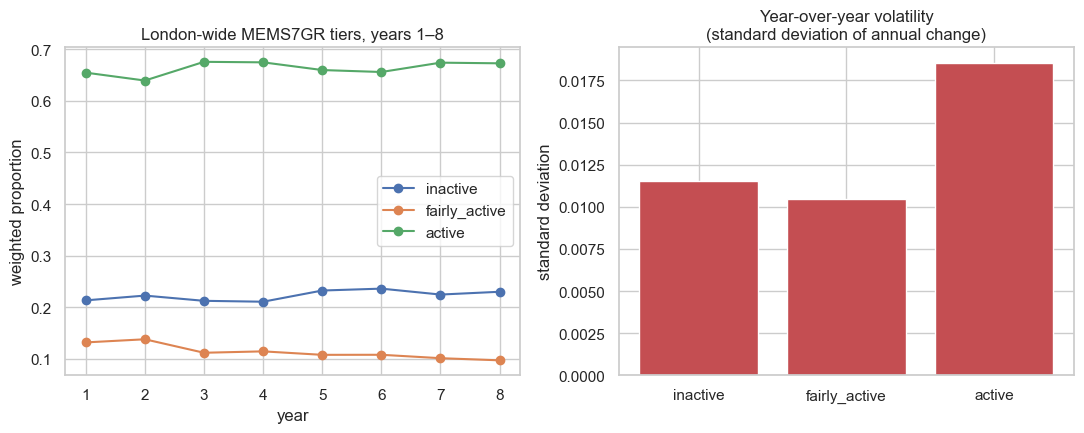

London-wide trend:
   year  inactive  fairly_active  active
0     1    0.2135         0.1320  0.6545
1     2    0.2227         0.1381  0.6392
2     3    0.2126         0.1120  0.6755
3     4    0.2108         0.1147  0.6745
4     5    0.2325         0.1079  0.6596
5     6    0.2362         0.1080  0.6558
6     7    0.2247         0.1014  0.6739
7     8    0.2301         0.0973  0.6726

Year-over-year volatility:
inactive         0.0115
fairly_active    0.0105
active           0.0186
dtype: float64


In [34]:
valid_overall = (
    dis_overall.dropna(
        subset=[
            'inactive_rate',
            'fairly_active_rate',
            'active_rate',
            'weighted_n'
        ]
    )
    .query('weighted_n > 0')
    .copy()
)

disab3_groups = [
    'limiting_disability',
    'non_limiting_disability',
    'no_disability'
]

valid_overall_disab3 = valid_overall[
    valid_overall['disability_group'].isin(disab3_groups)
].copy()

london_trend = (
    valid_overall_disab3
    .groupby('year')[
        [
            'inactive_rate',
            'fairly_active_rate',
            'active_rate',
            'weighted_n'
        ]
    ]
    .apply(
        lambda g: pd.Series({
            'inactive': np.average(
                g['inactive_rate'],
                weights=g['weighted_n']
            ),
            'fairly_active': np.average(
                g['fairly_active_rate'],
                weights=g['weighted_n']
            ),
            'active': np.average(
                g['active_rate'],
                weights=g['weighted_n']
            )
        })
    )
    .reset_index()
)

year_over_year_change = (
    london_trend[
        ['inactive', 'fairly_active', 'active']
    ]
    .diff()
    .dropna()
)

volatility = year_over_year_change.std()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for column in ['inactive', 'fairly_active', 'active']:
    axes[0].plot(
        london_trend['year'],
        london_trend[column],
        marker='o',
        label=column
    )

axes[0].set_title('London-wide MEMS7GR tiers, years 1–8')
axes[0].set_xlabel('year')
axes[0].set_ylabel('weighted proportion')
axes[0].legend()

axes[1].bar(
    volatility.index,
    volatility.values,
    color='#C44E52'
)
axes[1].set_title(
    'Year-over-year volatility\n'
    '(standard deviation of annual change)'
)
axes[1].set_ylabel('standard deviation')

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / 'figure_02_trend_and_volatility.png',
    dpi=150
)
plt.show()

print('London-wide trend:')
print(london_trend.round(4))

print()
print('Year-over-year volatility:')
print(volatility.round(4))

## 3. Activity participation concentration

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11056\2880355571.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


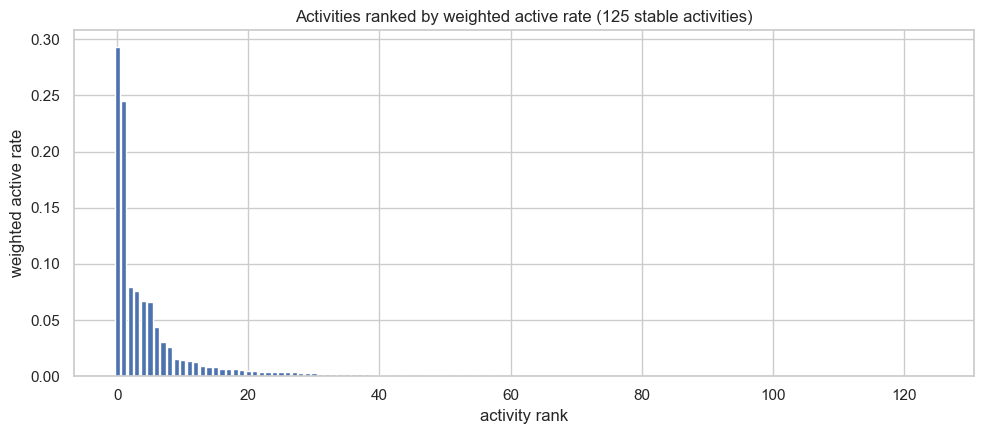

Number of activities: 125

Top 10 activities:
activity
ACTTRAV_C03       0.293249
WALKTRAV_B02      0.244791
GARD_B08          0.079502
RUNJOG_U07        0.075862
CYCTRAV_B04       0.066661
CYC_OLD_M02       0.065778
CYCLEISURE_N01    0.043387
FOOTBALL_F01      0.030249
DANCEOTHER_O01    0.026107
CYCROAD_N04       0.015309
dtype: float64


In [37]:
activity_participation = (
    dis_level[
        dis_level['disability_group'].isin(disab3_groups)
    ]
    .dropna(subset=['active_rate', 'weighted_n'])
    .query('weighted_n > 0')
    .groupby('activity')
    .apply(
        lambda g: np.average(
            g['active_rate'],
            weights=g['weighted_n']
        )
    )
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.bar(
    range(len(activity_participation)),
    activity_participation.values,
    color='#4C72B0'
)

ax.set_title(
    'Activities ranked by weighted active rate '
    '(125 stable activities)'
)
ax.set_xlabel('activity rank')
ax.set_ylabel('weighted active rate')

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / 'figure_03_activity_concentration.png',
    dpi=150
)
plt.show()

print('Number of activities:', len(activity_participation))

print()
print('Top 10 activities:')
print(activity_participation.head(10))

## 4. Disability sub-type co-occurrence (needs the raw individual-level files)


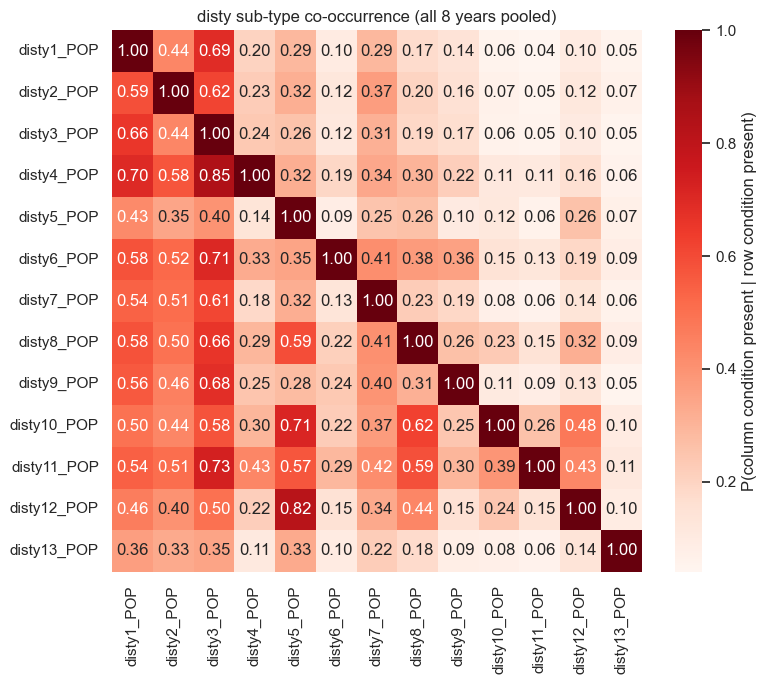

In [53]:
import os

root = r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20"
year_files = {
    1: os.path.join(root, "Yifeng Mao", "data", "active_lives_1516_london_125.csv"),
    2: os.path.join(root, "Yifeng Mao", "data", "active_lives_1617_london_125.csv"),
    3: os.path.join(root, "Siyan Xin", "2017~2018", "2017_data_125_activities.csv"),
    4: os.path.join(root, "Siyan Xin", "2018~2019", "2018_data_125_activities.csv"),
    5: os.path.join(root, "Shuhan Zhao", "docs", "1920_london32_stable125.csv"),
    6: os.path.join(root, "Shuhan Zhao", "docs", "2021_london32_stable125.csv"),
    7: os.path.join(root, "Jingyi Hua", "data", "processed", "year7_125activities.csv"),
    8: os.path.join(root, "Jingyi Hua", "data", "processed", "year8_125activities.csv"),
}

disty_cols = [f'disty{i}_POP' for i in range(1, 14)]

co_occurrence_frames = []
for year_number, file_path in year_files.items():
    header = pd.read_csv(file_path, nrows=0).columns
    col_lookup = {c.lower(): c for c in header}
    age_col = col_lookup.get('age16plus')
    if age_col is None:
        raise KeyError(f"Year {year_number} has no Age16plus-like column, check {file_path}")

    year_df = pd.read_csv(file_path, usecols=disty_cols + [age_col])
    year_df = year_df.rename(columns={age_col: 'Age16plus'})
    year_df = year_df[year_df['Age16plus'] == 1]
    co_occurrence_frames.append(year_df[disty_cols])

all_disty = pd.concat(co_occurrence_frames, ignore_index=True)
co_occurrence = pd.DataFrame(index=disty_cols, columns=disty_cols, dtype=float)
for a in disty_cols:
    has_a = all_disty[a] == 1
    for b in disty_cols:
        co_occurrence.loc[a, b] = (all_disty.loc[has_a, b] == 1).mean() if has_a.sum() > 0 else np.nan

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(co_occurrence.astype(float), annot=True, fmt='.2f', cmap='Reds', ax=ax,
            cbar_kws={'label': 'P(column condition present | row condition present)'})
ax.set_title('disty sub-type co-occurrence (all 8 years pooled)')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_04_disty_co_occurrence.png', dpi=150)
plt.show()


## 5. How the three outcome measures relate to each other



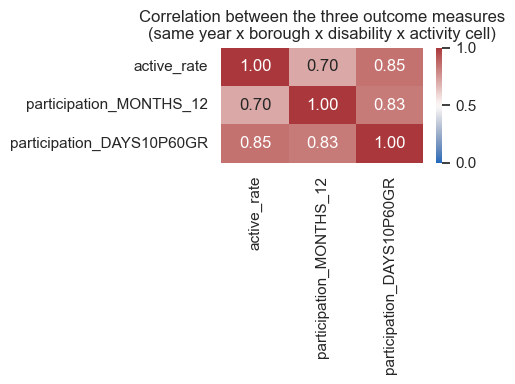

                           active_rate  participation_MONTHS_12  \
active_rate                      1.000                    0.704   
participation_MONTHS_12          0.704                    1.000   
participation_DAYS10P60GR        0.851                    0.826   

                           participation_DAYS10P60GR  
active_rate                                    0.851  
participation_MONTHS_12                        0.826  
participation_DAYS10P60GR                      1.000  


In [39]:
merged_targets = dis_level.merge(
    dis_dm, on=['year', 'LA_2023', 'disability_group', 'activity'], how='inner'
)

correlation_matrix = merged_targets[
    ['active_rate', 'participation_MONTHS_12', 'participation_DAYS10P60GR']
].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='vlag', vmin=0, vmax=1, ax=ax)
ax.set_title('Correlation between the three outcome measures\n(same year x borough x disability x activity cell)')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_05_outcome_correlation.png', dpi=150)
plt.show()

print(correlation_matrix.round(3))


## 6. Summary tables


In [40]:
summary_tables_dir = FIGURE_DIR.parent / 'pre_eda_tables'
summary_tables_dir.mkdir(parents=True, exist_ok=True)

by_borough.rename('small_cell_rate').to_csv(summary_tables_dir / 'small_cell_rate_by_borough.csv')
by_group.rename('small_cell_rate').to_csv(summary_tables_dir / 'small_cell_rate_by_disability_group.csv')
london_trend.to_csv(summary_tables_dir / 'london_trend_by_year.csv', index=False)
volatility.rename('year_over_year_volatility').to_csv(summary_tables_dir / 'year_over_year_volatility.csv')
activity_participation.rename('weighted_active_rate').to_csv(summary_tables_dir / 'activity_participation_ranked.csv')
co_occurrence.to_csv(summary_tables_dir / 'disty_co_occurrence.csv')
correlation_matrix.to_csv(summary_tables_dir / 'outcome_measure_correlation.csv')

print('Saved tables to', summary_tables_dir)


Saved tables to C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\pre_eda_tables


## 7. Observed contrasts (statistical significance)

In [41]:
from scipy import stats

contingency = pd.crosstab(dis_level['LA_2023'], dis_level['small_cell'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

n_obs = contingency.sum().sum()
degrees_of_freedom = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n_obs * degrees_of_freedom))

print(f'small-cell rate vs borough: chi2={chi2:.1f}, p={p_value:.4g}, Cramér\'s V={cramers_v:.4f}')
print('Cramér\'s V guide: ~0.1 small, ~0.3 medium, ~0.5 large')

small-cell rate vs borough: chi2=5204.4, p=0, Cramér's V=0.1009
Cramér's V guide: ~0.1 small, ~0.3 medium, ~0.5 large


In [42]:
disab3_subset = dis_level[
    dis_level['disability_group'].isin(['limiting_disability', 'non_limiting_disability', 'no_disability'])
]
groups = [g['active_rate'].dropna() for _, g in disab3_subset.groupby('disability_group')]
h_statistic, p_value = stats.kruskal(*groups)

epsilon_squared = (h_statistic - len(groups) + 1) / (len(disab3_subset) - len(groups))
print(f'active_rate across Disab3: H={h_statistic:.1f}, p={p_value:.4g}, epsilon-squared={epsilon_squared:.4f}')
print('epsilon-squared guide: ~0.01 small, ~0.08 medium, ~0.26 large')

print(disab3_subset.groupby('disability_group')['active_rate'].median())

active_rate across Disab3: H=4204.4, p=0, epsilon-squared=0.0438
epsilon-squared guide: ~0.01 small, ~0.08 medium, ~0.26 large
disability_group
limiting_disability        0.0
no_disability              0.0
non_limiting_disability    0.0
Name: active_rate, dtype: float64


In [43]:
co_occurrence_significance = pd.DataFrame(index=disty_cols, columns=disty_cols, dtype=float)

for a in disty_cols:
    for b in disty_cols:
        if a == b:
            continue
        table = pd.crosstab(all_disty[a], all_disty[b])
        if table.shape == (2, 2):
            _, p_value = stats.fisher_exact(table, alternative='greater')
            co_occurrence_significance.loc[a, b] = p_value

print('Pairs with non-significant co-occurrence (p > 0.05), if the earlier heatmap suggested independence was reasonable:')
print(co_occurrence_significance[co_occurrence_significance > 0.05].stack())

Pairs with non-significant co-occurrence (p > 0.05), if the earlier heatmap suggested independence was reasonable:
Series([], dtype: float64)


## 8. Activity availability summary

In [44]:
import pandas as pd

PROCESSED_DIR = r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed"

path_mems = f"{PROCESSED_DIR}\\RQ3_borough_disability_MEMS7GR_all_years.csv"
path_days_months = f"{PROCESSED_DIR}\\RQ3_borough_disability_days_months_all_years.csv"

df_mems = pd.read_csv(path_mems)
df_dm = pd.read_csv(path_days_months)

print("MEMS7GR list name:", list(df_mems.columns))
print("days_months list name:", list(df_dm.columns))

MEMS7GR list name: ['year', 'LA_2023', 'disability_group', 'activity', 'inactive_rate', 'fairly_active_rate', 'active_rate', 'n', 'weighted_n']
days_months list name: ['year', 'LA_2023', 'disability_group', 'activity', 'participation_DAYS10P60GR', 'n_DAYS10P60GR', 'weighted_n_DAYS10P60GR', 'participation_MONTHS_12', 'n_MONTHS_12', 'weighted_n_MONTHS_12']


In [45]:
# --- Which years each activity has non-missing MEMS7GR data ---

mems_availability = (
    df_mems.dropna(subset=['active_rate'])
    .groupby('activity')['year']
    .apply(lambda s: sorted(s.unique()))
    .rename('mems7gr_years')
)

print(mems_availability.head())

# --- Which years each activity has MONTHS_12 / DAYS10P60GR data ---

months12_availability = (
    df_dm.dropna(subset=['participation_MONTHS_12'])
    .groupby('activity')['year']
    .apply(lambda s: sorted(s.unique()))
    .rename('months12_years')
)

days_availability = (
    df_dm.dropna(subset=['participation_DAYS10P60GR'])
    .groupby('activity')['year']
    .apply(lambda s: sorted(s.unique()))
    .rename('days10p60gr_years')
)

print(months12_availability.head())
print(days_availability.head())

# --- Merge into one availability summary, also listing the specific missing years ---

ALL_YEARS = set(range(1, 9))
all_activities = sorted(set(df_mems['activity'].unique()) | set(df_dm['activity'].unique()))

records = []
for act in all_activities:
    mems_years = set(mems_availability.get(act, []))
    months_years = set(months12_availability.get(act, []))
    days_years = set(days_availability.get(act, []))

    records.append({
        'activity_suffix': act,
        'activity_level_years_available': len(mems_years),
        'activity_level_missing_years': sorted(ALL_YEARS - mems_years),
        'months12_years_available': len(months_years),
        'months12_missing_years': sorted(ALL_YEARS - months_years),
        'days10p60gr_years_available': len(days_years),
        'days10p60gr_missing_years': sorted(ALL_YEARS - days_years),
        'complete_for_participation': (len(months_years) == 8) and (len(days_years) == 8),
        'complete_for_participation_and_level': (
            len(months_years) == 8 and len(days_years) == 8 and len(mems_years) == 8
        ),
    })

availability_df = pd.DataFrame(records)

out_path = f"{PROCESSED_DIR}\\RQ3_disability_activity_availability_summary.csv"
availability_df.to_csv(out_path, index=False)

print(availability_df['complete_for_participation_and_level'].value_counts())
availability_df.head(10)

activity
ABSEILING_H03    [1, 2, 3, 4, 5, 6, 7, 8]
ACTTRAV_C03      [1, 2, 3, 4, 5, 6, 7, 8]
AIKIDO_S04       [1, 2, 3, 4, 5, 6, 7, 8]
AIRGUN_S08       [1, 2, 3, 4, 5, 6, 7, 8]
ARCHERY_J01      [1, 2, 3, 4, 5, 6, 7, 8]
Name: mems7gr_years, dtype: object
activity
ABSEILING_H03    [1, 2, 3, 4, 5, 6, 7, 8]
ACTTRAV_C03      [1, 2, 3, 4, 5, 6, 7, 8]
AIKIDO_S04       [1, 2, 3, 4, 5, 6, 7, 8]
AIRGUN_S08       [1, 2, 3, 4, 5, 6, 7, 8]
ARCHERY_J01      [1, 2, 3, 4, 5, 6, 7, 8]
Name: months12_years, dtype: object
activity
ABSEILING_H03    [1, 2, 3, 4, 5, 6, 7, 8]
ACTTRAV_C03      [1, 2, 3, 4, 5, 6, 7, 8]
AIKIDO_S04       [1, 2, 3, 4, 5, 6, 7, 8]
AIRGUN_S08       [1, 2, 3, 4, 5, 6, 7, 8]
ARCHERY_J01      [1, 2, 3, 4, 5, 6, 7, 8]
Name: days10p60gr_years, dtype: object
complete_for_participation_and_level
True     124
False      1
Name: count, dtype: int64


,activity_suffix,activity_level_years_available,activity_level_missing_years,months12_years_available,months12_missing_years,days10p60gr_years_available,days10p60gr_missing_years,complete_for_participation,complete_for_participation_and_level
0,ABSEILING_H03,8,[],8,[],8,[],True,True
1,ACTTRAV_C03,8,[],8,[],8,[],True,True
2,AIKIDO_S04,8,[],8,[],8,[],True,True
3,AIRGUN_S08,8,[],8,[],8,[],True,True
4,ARCHERY_J01,8,[],8,[],8,[],True,True
5,BADMINTON_G02,8,[],8,[],8,[],True,True
6,BASESOFTBALL_F13,8,[],8,[],8,[],True,True
7,BASKETBALL_F07,8,[],8,[],8,[],True,True
8,BOCCIA_L11,8,[],8,[],8,[],True,True
9,BOULES_L12,8,[],8,[],8,[],True,True


## 9. Add small_cell_warning column to flag unreliable small-n estimates

In [46]:
import pandas as pd

PROCESSED_DIR = r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed"

# --- MEMS7GR activity-level table ---
path_mems = f"{PROCESSED_DIR}\\RQ3_borough_disability_MEMS7GR_all_years.csv"
df_mems = pd.read_csv(path_mems)
df_mems['small_cell_warning'] = df_mems['n'] < 30
df_mems.to_csv(path_mems, index=False)
print('mems table small_cell_warning rate:', df_mems['small_cell_warning'].mean().round(3))

# --- overall-level table ---
path_overall = f"{PROCESSED_DIR}\\RQ3_borough_disability_overall_all_years.csv"
df_overall = pd.read_csv(path_overall)
df_overall['small_cell_warning'] = df_overall['n'] < 30
df_overall.to_csv(path_overall, index=False)
print('overall table small_cell_warning rate:', df_overall['small_cell_warning'].mean().round(3))

# --- days_months table ---
path_dm = f"{PROCESSED_DIR}\\RQ3_borough_disability_days_months_all_years.csv"
df_dm = pd.read_csv(path_dm)
df_dm['small_cell_warning_months12'] = df_dm['n_MONTHS_12'] < 30
df_dm['small_cell_warning_days10p60gr'] = df_dm['n_DAYS10P60GR'] < 30
df_dm.to_csv(path_dm, index=False)
print('days_months table months12 small_cell rate:', df_dm['small_cell_warning_months12'].mean().round(3))
print('days_months table days10p60gr small_cell rate:', df_dm['small_cell_warning_days10p60gr'].mean().round(3))

mems table small_cell_warning rate: 0.692
overall table small_cell_warning rate: 0.672
days_months table months12 small_cell rate: 0.721
days_months table days10p60gr small_cell rate: 0.721


## 10. Missingness rate of disability flag variables themselves (all 8 years)

In [47]:
from pathlib import Path

output_path = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\disty_missingness_all_years.txt")
output_path.parent.mkdir(parents=True, exist_ok=True)

disty_cols = [f'disty{i}_POP' for i in range(1, 14)]

with open(output_path, 'w') as f:
    for year_number, file_path in year_files.items():
        header = pd.read_csv(file_path, nrows=0).columns
        col_lookup = {c.lower(): c for c in header}
        age_col = col_lookup.get('age16plus')
        disab3_col = col_lookup.get('disab3')
        if age_col is None or disab3_col is None:
            raise KeyError(f"Year {year_number} missing Age16plus or Disab3 column, check {file_path}")

        cols_to_read = list(dict.fromkeys([age_col, disab3_col] + disty_cols))
        year_df = pd.read_csv(file_path, usecols=cols_to_read)
        year_df = year_df.rename(columns={age_col: 'Age16plus', disab3_col: 'Disab3'})
        year_df = year_df[year_df['Age16plus'] == 1]

        f.write(f"--- Year {year_number} ---\n")
        f.write(f"total respondents: {len(year_df)}\n")

        disab3_missing = year_df['Disab3'].isna().sum()
        f.write(f"Disab3 missing: {disab3_missing} ({disab3_missing / len(year_df):.3%})\n")

        for col in disty_cols:
            n_missing = year_df[col].isna().sum()
            f.write(f"{col} missing: {n_missing} ({n_missing / len(year_df):.3%})\n")
        f.write("\n")

print("saved to", output_path)

saved to C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\disty_missingness_all_years.txt


## 11. Quantifying the COVID structural break (Year5-6 vs linear trend)

In [48]:
non_covid_years = london_trend[~london_trend['year'].isin([5, 6])].copy()
covid_years = london_trend[london_trend['year'].isin([5, 6])].copy()

slope, intercept = np.polyfit(non_covid_years['year'], non_covid_years['active'], 1)

london_trend['predicted_active'] = slope * london_trend['year'] + intercept
london_trend['residual'] = london_trend['active'] - london_trend['predicted_active']
london_trend['abs_residual'] = london_trend['residual'].abs()

print("Linear trend fitted on years excluding 5 and 6:")
print(f"slope={slope:.5f}, intercept={intercept:.5f}")
print()
print(london_trend[['year', 'active', 'predicted_active', 'residual', 'abs_residual']])
print()

non_covid_residual_mean = london_trend.loc[~london_trend['year'].isin([5, 6]), 'abs_residual'].mean()
covid_residual_mean = london_trend.loc[london_trend['year'].isin([5, 6]), 'abs_residual'].mean()

print(f"mean abs residual, non-COVID years: {non_covid_residual_mean:.5f}")
print(f"mean abs residual, COVID years (5,6): {covid_residual_mean:.5f}")
print(f"ratio: {covid_residual_mean / non_covid_residual_mean:.2f}x")

Linear trend fitted on years excluding 5 and 6:
slope=0.00333, intercept=0.65115

   year    active  predicted_active  residual  abs_residual
0     1  0.654529          0.654484  0.000045      0.000045
1     2  0.639241          0.657817 -0.018576      0.018576
2     3  0.675484          0.661150  0.014334      0.014334
3     4  0.674501          0.664483  0.010018      0.010018
4     5  0.659565          0.667816 -0.008251      0.008251
5     6  0.655785          0.671149 -0.015364      0.015364
6     7  0.673874          0.674481 -0.000608      0.000608
7     8  0.672600          0.677814 -0.005214      0.005214

mean abs residual, non-COVID years: 0.00813
mean abs residual, COVID years (5,6): 0.01181
ratio: 1.45x


In [49]:
group_trend = (
    valid_overall.groupby(['year', 'disability_group'])[['inactive_rate', 'fairly_active_rate', 'active_rate', 'weighted_n']]
    .apply(lambda g: pd.Series({
        'active': np.average(g['active_rate'], weights=g['weighted_n']),
    }))
    .reset_index()
)

results = []
for group_name, g in group_trend.groupby('disability_group'):
    g = g.sort_values('year')
    non_covid = g[~g['year'].isin([5, 6])]

    if len(non_covid) < 2:
        continue

    slope, intercept = np.polyfit(non_covid['year'], non_covid['active'], 1)
    g = g.copy()
    g['predicted_active'] = slope * g['year'] + intercept
    g['abs_residual'] = (g['active'] - g['predicted_active']).abs()

    non_covid_mean = g.loc[~g['year'].isin([5, 6]), 'abs_residual'].mean()
    covid_mean = g.loc[g['year'].isin([5, 6]), 'abs_residual'].mean()

    results.append({
        'disability_group': group_name,
        'non_covid_mean_abs_residual': non_covid_mean,
        'covid_mean_abs_residual': covid_mean,
        'ratio': covid_mean / non_covid_mean if non_covid_mean > 0 else np.nan,
    })

covid_by_group = pd.DataFrame(results).sort_values('ratio', ascending=False)
print(covid_by_group.round(4).to_string(index=False))

       disability_group  non_covid_mean_abs_residual  covid_mean_abs_residual  ratio
          no_disability                       0.0094                   0.0197 2.0958
                 disty8                       0.0255                   0.0479 1.8780
                 disty9                       0.0334                   0.0372 1.1139
                 disty6                       0.0547                   0.0488 0.8930
                disty13                       0.0417                   0.0357 0.8561
                disty10                       0.0392                   0.0331 0.8451
                 disty3                       0.0121                   0.0084 0.6942
                 disty2                       0.0216                   0.0134 0.6203
                 disty4                       0.0339                   0.0195 0.5771
                 disty7                       0.0252                   0.0129 0.5121
                disty12                       0.0406             

## 12. Lag-1 autocorrelation check

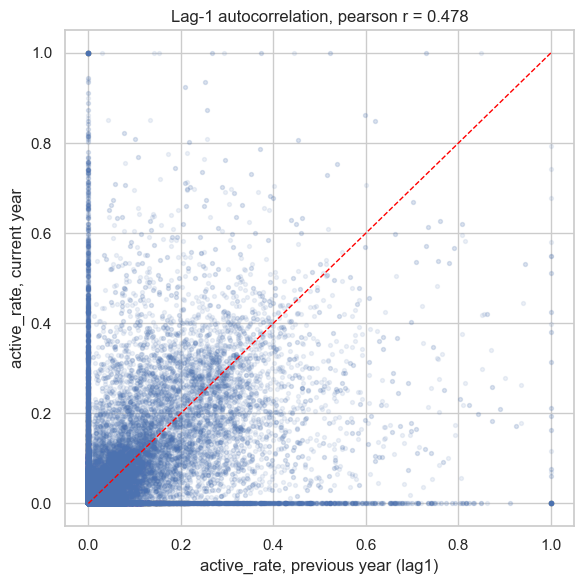

pearson r = 0.4776, p = 0.00e+00, n = 440649


In [50]:
from scipy.stats import pearsonr

panel_keys = ['LA_2023', 'disability_group', 'activity']

lag_check = dis_level.dropna(subset=['active_rate']).sort_values('year').copy()
lag_check['active_rate_lag1'] = lag_check.groupby(panel_keys)['active_rate'].shift(1)
lag_check = lag_check.dropna(subset=['active_rate_lag1'])

r_value, p_value = pearsonr(lag_check['active_rate_lag1'], lag_check['active_rate'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(lag_check['active_rate_lag1'], lag_check['active_rate'], alpha=0.1, s=8)
ax.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1)
ax.set_xlabel('active_rate, previous year (lag1)')
ax.set_ylabel('active_rate, current year')
ax.set_title(f'Lag-1 autocorrelation, pearson r = {r_value:.3f}')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_12_lag1_autocorrelation.png', dpi=150)
plt.show()

print(f'pearson r = {r_value:.4f}, p = {p_value:.2e}, n = {len(lag_check)}')

## 13. Disability activity gap over time

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11056\1763860494.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['active_rate'], weights=g['weighted_n']))


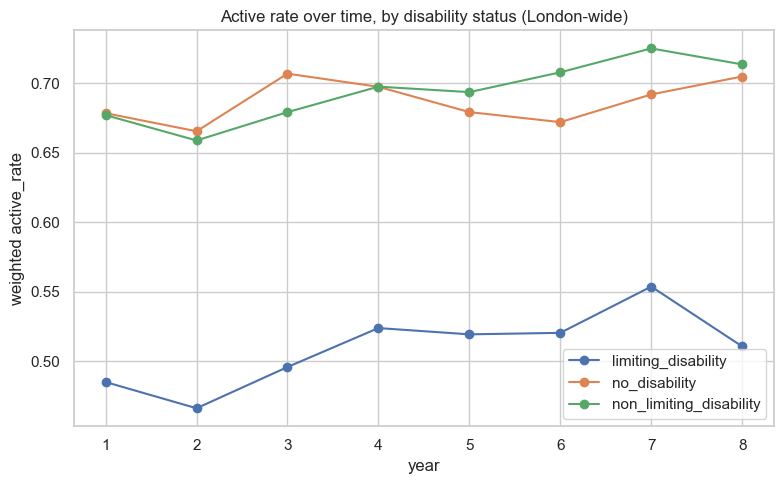

disability_group  limiting_disability  no_disability  non_limiting_disability  \
year                                                                            
1                              0.4851         0.6786                   0.6772   
2                              0.4662         0.6656                   0.6590   
3                              0.4959         0.7071                   0.6794   
4                              0.5239         0.6976                   0.6977   
5                              0.5194         0.6794                   0.6938   
6                              0.5205         0.6722                   0.7080   
7                              0.5538         0.6921                   0.7252   
8                              0.5107         0.7050                   0.7137   

disability_group  gap_limiting_vs_no_disability  
year                                             
1                                        0.1935  
2                                      

In [51]:
disab3_trend = (
    valid_overall[valid_overall['disability_group'].isin(
        ['limiting_disability', 'non_limiting_disability', 'no_disability']
    )]
    .groupby(['year', 'disability_group'])
    .apply(lambda g: np.average(g['active_rate'], weights=g['weighted_n']))
    .rename('active')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
for group_name, g in disab3_trend.groupby('disability_group'):
    g = g.sort_values('year')
    ax.plot(g['year'], g['active'], marker='o', label=group_name)

ax.set_xlabel('year')
ax.set_ylabel('weighted active_rate')
ax.set_title('Active rate over time, by disability status (London-wide)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_13_disability_gap_trend.png', dpi=150)
plt.show()

gap = disab3_trend.pivot(index='year', columns='disability_group', values='active')
gap['gap_limiting_vs_no_disability'] = gap['no_disability'] - gap['limiting_disability']
print(gap.round(4))

## 14. Spatial heterogeneity across London boroughs

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11056\442445514.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


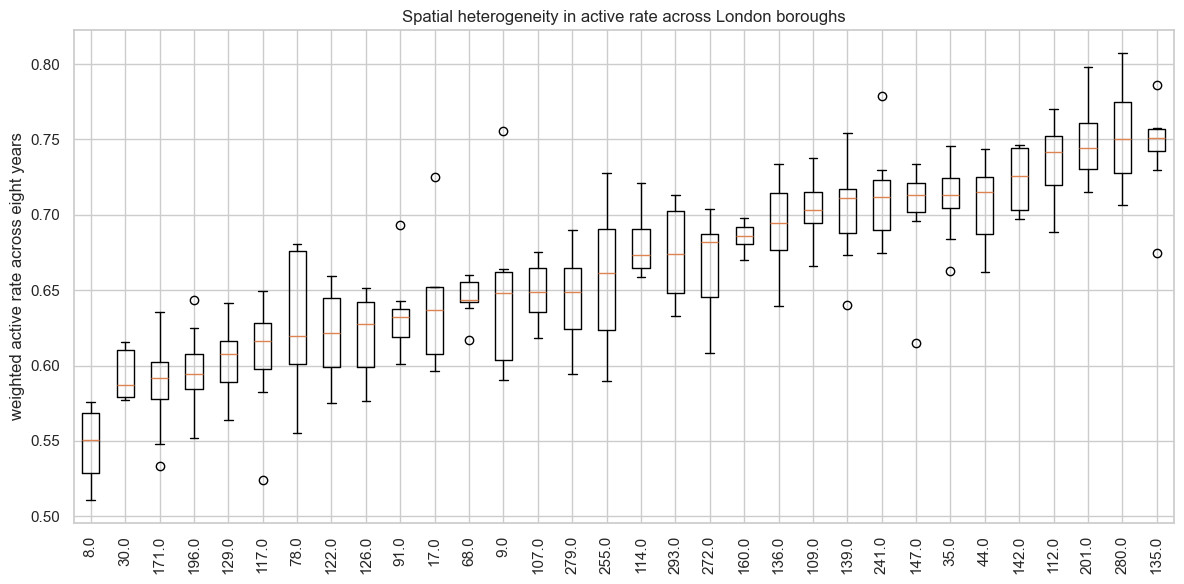

         median     std
LA_2023                
8.0      0.5505  0.0266
30.0     0.5871  0.0166
171.0    0.5920  0.0350
196.0    0.5944  0.0280
129.0    0.6077  0.0235
117.0    0.6162  0.0385
78.0     0.6195  0.0462
122.0    0.6214  0.0304
126.0    0.6273  0.0278
91.0     0.6325  0.0277
17.0     0.6371  0.0414
68.0     0.6437  0.0139
9.0      0.6478  0.0531
107.0    0.6486  0.0197
279.0    0.6489  0.0315
255.0    0.6612  0.0518
114.0    0.6734  0.0214
293.0    0.6742  0.0315
272.0    0.6821  0.0333
160.0    0.6861  0.0093
136.0    0.6947  0.0344
109.0    0.7034  0.0224
139.0    0.7111  0.0346
241.0    0.7118  0.0335
147.0    0.7133  0.0375
35.0     0.7133  0.0269
44.0     0.7152  0.0293
142.0    0.7260  0.0223
112.0    0.7418  0.0300
201.0    0.7445  0.0266
280.0    0.7504  0.0364
135.0    0.7511  0.0321

Range across boroughs (maximum median minus minimum median): 0.2006


In [52]:
borough_trend = (
    valid_overall_disab3
    .groupby(['LA_2023', 'year'])
    .apply(
        lambda g: np.average(
            g['active_rate'],
            weights=g['weighted_n']
        )
    )
    .rename('active')
    .reset_index()
)

order = (
    borough_trend
    .groupby('LA_2023')['active']
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(12, 6))

data = [
    borough_trend.loc[
        borough_trend['LA_2023'] == borough,
        'active'
    ].values
    for borough in order
]

ax.boxplot(
    data,
    tick_labels=order,
    vert=True
)

ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('weighted active rate across eight years')
ax.set_title(
    'Spatial heterogeneity in active rate '
    'across London boroughs'
)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / 'figure_14_borough_boxplot.png',
    dpi=150
)
plt.show()

borough_summary = (
    borough_trend
    .groupby('LA_2023')['active']
    .agg(['median', 'std'])
    .sort_values('median')
)

print(borough_summary.round(4))

borough_range = (
    borough_summary['median'].max()
    - borough_summary['median'].min()
)

print()
print(
    'Range across boroughs '
    '(maximum median minus minimum median):',
    round(borough_range, 4)
)